# Reproduced Figure 2

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

#=====================================================================
# ! IMPORTANT: UPDATE THIS PATH FOR YOUR OWN MACHINE!  
# 
# ➤ Please replace it with the full path to your "WD-IMBH-Relativistic-Tides" folder.
#   Example:
#        sys.path.append("/Users/your_username/your_project_folder/WD-IMBH-Relativistic-Tides")
#
#  Tip: Keep this notebook in the same directory as the "WD-IMBH-Relativistic-Tides" folder for easier path management.
import os 
os.chdir("/your_username/your_project_folder/WD-IMBH-Relativistic-Tides") 
# os.chdir("/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides")
print(os.getcwd())
#=====================================================================


/Users/yang/My_Project_Files_Yang_Yang/WD-IMBH-Relativistic-Tides


In [2]:
# Boundary of unstable orbits
# Here, we transform the relationship satisfied by the boundaries of unstable orbits into a set of differential equations for calculation
# Original function
for iiii in range(1):
    def Unstable_eq_function(rp, e, a):
        p = rp * (1 + e)
        F = p**(-3) * (
            p**3
            - 2 * (3 + e**2) * p**2
            + (3 + e**2)**2 * p
            - 4 * a**2 * (1 - e**2)**2
        )
        N = 2 / p * (
            -p**2
            + ((3 + e**2) - a**2) * p
            - a**2 * (1 + 3 * e**2)
        )
        C = (a**2 - p)**2
        Delta_x = N**2 - 4 * F * C
        return Delta_x - (2 * F * p**2 / ((1 + e) * (3 - e)) + N)**2

    def F(rp, e, a):
        return Unstable_eq_function(rp, e, a)

    # Compute partial derivatives
    def dF_drp(rp, e, a, h=1e-6):
        return (F(rp + h, e, a) - F(rp - h, e, a)) / (2 * h)

    def dF_de(rp, e, a, h=1e-6):
        return (F(rp, e + h, a) - F(rp, e - h, a)) / (2 * h)

    # Define the right-hand side of the ODE
    def drp_de(e, rp, a):
        """Compute dr_p / de"""
        rp = rp[0]  # scipy.integrate.solve_ivp passes an array
        df_drp = dF_drp(rp, e, a)
        df_de = dF_de(rp, e, a)

        if abs(df_drp) < 1e-12:
            # Derivative near zero → vertical tangent; integration cannot proceed
            return [0.0]

        return [-abs(df_de / df_drp)]

# Integrate using solve_ivp
from scipy.integrate import solve_ivp

def solve_rp_function(a):
    e0 = 0  # Known value of eccentricity e
    # Compute initial rp0
    Z1 = 1 + (1 - a**2)**(1/3) * ((1 + a)**(1/3) + (1 - a)**(1/3))
    Z2 = (3 * a**2 + Z1**2)**(1/2)
    rp0 = 3 + Z2 - np.sign(a) * ((3 - Z1) * (3 + Z1 + 2 * Z2))**(1/2)  # Corresponding correct rp value
    rp0 = rp0 * 1

    # Forward integration to e = 0.999, backward to e = 0.001
    sol_forward = solve_ivp(
        fun=lambda e, y: drp_de(e, y, a),
        t_span=(e0, 0.999),
        y0=[rp0],
        method='RK45',
        max_step=0.01,
        rtol=1e-6,
        atol=1e-10
    )

    sol_backward = solve_ivp(
        fun=lambda e, y: drp_de(e, y, a),
        t_span=(e0, 0.001),
        y0=[rp0],
        method='RK45',
        max_step=0.01,
        rtol=1e-6,
        atol=1e-12
    )

    # Combine results
    e_full = np.concatenate([sol_backward.t[::-1], sol_forward.t[1:]])
    rp_full = np.concatenate([sol_backward.y[0][::-1], sol_forward.y[0][1:]])

    # Create interpolation function
    rp_interp = interp1d(e_full, rp_full, kind='cubic', fill_value="extrapolate")

    return rp_interp

In [3]:
# Define some physical quantities
def WD_R_M(M_WD):  
    return 6120*(M_WD/1.44)**(-1/3)*(1-M_WD/1.44)**(0.447)  
def WD_eta(M_WD): 
    return (M_WD/WD_R_M(M_WD))**(1/2)

In [4]:
#==================================================== 
# Fixed parameters: white dwarf mass and black hole mass
M_WD = 0.6
M_BH = 1e5
R_BH = M_BH  # Resulting unit is in solar gravitational radii (r_g)
R_star = WD_R_M(M_WD)  # Resulting unit is in solar gravitational radii (r_g)
ratio_R_star_R_BH = R_star / R_BH
ratio_sqrt_v_star_c = WD_eta(M_WD)
r_t = ratio_R_star_R_BH * (M_BH / M_WD)**(1/3)

In [5]:
# Load the interpolated tidal disruption radius function and evaluate it on a grid of spin parameter a and eccentricity e.
from joblib import load 
if M_BH==4e5 and M_WD==0.6:
    rp_rt_a_e_interpolant = load("rt_interpolant_function/rp_rt_a_e_BH4_WD6.joblib")
elif M_BH==4e5 and M_WD==0.3:
    rp_rt_a_e_interpolant = load("rt_interpolant_function/rp_rt_a_e_BH4_WD3.joblib")
elif M_BH==1e5 and M_WD==0.6:
    rp_rt_a_e_interpolant = load("rt_interpolant_function/rp_rt_a_e_BH1_WD6.joblib")
elif M_BH==1e5 and M_WD==0.3:
    rp_rt_a_e_interpolant = load("rt_interpolant_function/rp_rt_a_e_BH1_WD3.joblib")


In [6]:
# we use rp_a_e_unstable_interpolant and rp_rt_a_e_interpolant 
a_net2 = np.linspace( -0.95, 0.95,   int(2*80+1)  )
e_net2 = np.linspace( 0.05, 0.96,   int(2*80+1)  )

rp_a_e_unstable = np.zeros((len(a_net2),len(e_net2)))
rp_rt_a_e_table = np.zeros((len(a_net2),len(e_net2)))
for i, a_test  in enumerate(a_net2):   
    rp_plunge_limit_line_fun = solve_rp_function(a_test)
    for j, e_test  in enumerate(e_net2):   
        rp_a_e_unstable[i][j] = rp_plunge_limit_line_fun(e_test) 
        rp_rt_a_e_table[i][j] = rp_rt_a_e_interpolant([a_test,e_test])[0]


In [7]:
# --- 1. Compute the ratio ---
ratio = rp_a_e_unstable / rp_rt_a_e_table
ratio = np.where(np.isfinite(ratio), ratio, np.nan)

# --- 2. Create meshgrid ---
A, E = np.meshgrid(a_net2, e_net2, indexing='ij')

# --- 3. Extract the contour where ratio = 1 ---
contour_set = plt.contour(E, A, ratio, levels=[1.0])
plt.close()  # Do not display the plot

# --- 4. Extract contour points (using .allsegs) ---
# contour_set.allsegs is a list with length = len(levels)
# Since we passed levels=[1.0], allsegs[0] contains all segments for ratio = 1
e_points = []
a_points = []

for segment in contour_set.allsegs[0]:  # allsegs[0] contains all connected/disconnected segments at ratio=1
    if len(segment) > 1:
        e_vals = segment[:, 0]   # x-coordinate = eccentricity (e)
        a_vals = segment[:, 1]   # y-coordinate = spin parameter (a)
        e_points.append(e_vals)
        a_points.append(a_vals)

if not e_points:
    raise ValueError("No contour found at ratio = 1!")

# --- 5. Merge and sort points ---
e_all = np.concatenate(e_points)
a_all = np.concatenate(a_points)

# Keep only finite values
valid = np.isfinite(e_all) & np.isfinite(a_all)
e_all = e_all[valid]
a_all = a_all[valid]

# Sort by eccentricity e (assuming a functional relationship a(e))
sort_idx = np.argsort(e_all)
e_sorted = e_all[sort_idx]
a_sorted = a_all[sort_idx]

# Remove duplicates to avoid interpolation errors
_, unique_idx = np.unique(e_sorted, return_index=True)
e_unique = e_sorted[unique_idx]
a_unique = a_sorted[unique_idx]

# --- 6. Build interpolation function ---
a_crit_of_e = interp1d(
    e_unique, a_unique,
    kind='linear',
    bounds_error=False,
    fill_value=np.nan
)

/var/folders/mk/3bs2cv5d75v1lbfzvj94r0km0000gn/T/ipykernel_4261/4200137557.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


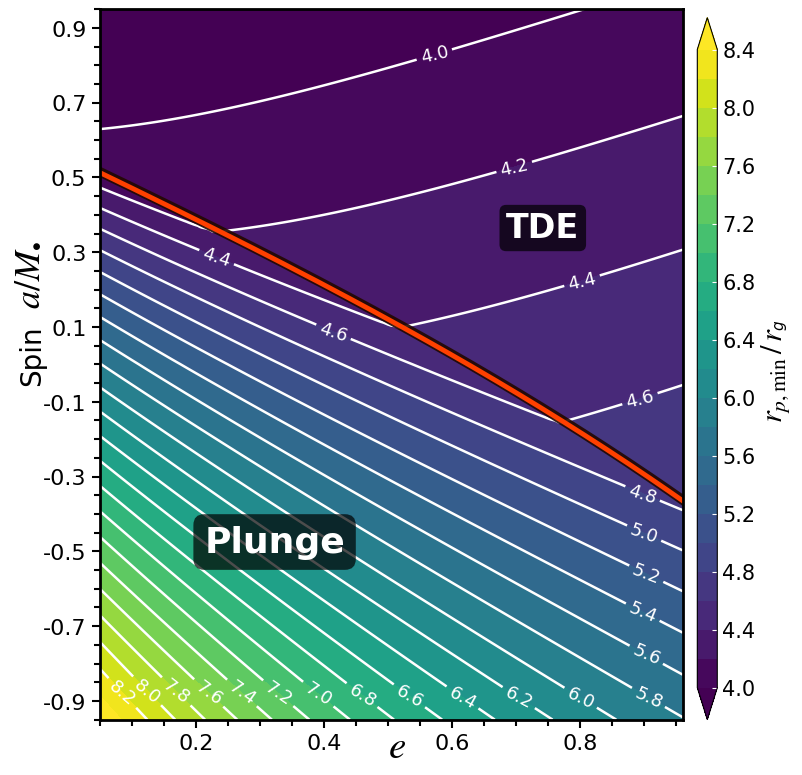

In [10]:
# Please execute this code cell twice repeatedly, so that the font can be executed

# --- 1. Prepare data ---

# Create meshgrid
A, E = np.meshgrid(a_net2, e_net2, indexing='ij')  # A[i,j] = a_i, E[i,j] = e_j

# --- 2. Compute critical spin a_crit(e) ---
a_crit_grid = a_crit_of_e(E)  # shape (Na, Ne): critical a for each e

# --- 3. Determine regions ---
# Lower region: a < a_crit → use unstable orbit radius
# Upper region: a >= a_crit → use tidal disruption radius
mask_lower = A < a_crit_grid  # shape (Na, Ne)
mask_upper = A >= a_crit_grid

# Construct final rp field
rp_final = np.full_like(rp_a_e_unstable, np.nan)
rp_final[mask_lower] = rp_a_e_unstable[mask_lower]
rp_final[mask_upper] = rp_rt_a_e_table[mask_upper]

# --- 4. Plotting ---
fig, ax = plt.subplots(figsize=(8, 7.8))

# Plot filled contours
levels = [v for v in [x / 10 for x in range(40, 83, 2)] if v not in {4.0, 4.2, 4.4, 4.6, 5.0, 5.4}]

cf = ax.contourf(E, A, rp_final, levels=30, cmap='viridis', extend='both')

# Add some contour lines
contours = ax.contour(E, A, rp_final, levels=levels, colors='white', linewidths=1.8, alpha=1)
ax.clabel(contours, inline=True, fontsize=13, fmt='%.1f', colors="#ffffff")

# Draw specific contour lines again for emphasis
contours = ax.contour(E, A, rp_final, levels=[4.0, 4.2, 4.4, 4.6, 5.0, 5.4], 
                        colors='white', linewidths=1.8, alpha=1)

# Manually specify label positions
manual_locations = [
    (0.57, 0.85),   # 4.0
    (0.7, 0.5),     # 4.2
    (0.8, 0.25),    # 4.4
    (0.23, 0.27),   # 4.4  
    (0.9, -0.15),   # 4.6
    (0.42, 0.12),   # 4.6  
    (0.9, -0.45),   # 5.0
    (0.9, -0.65)    # 5.4
]
ax.clabel(contours, manual=manual_locations, fontsize=13, colors='#ffffff', fmt='%.1f')

ax.set_yticks(np.arange(-0.9, 1.0, 0.2))  # from -0.9 to 0.9, step 0.2
ax.set_yticklabels([f'{x:.1f}' for x in np.arange(-0.9, 1.0, 0.2)])

# Add colorbar
# 1. Define precise levels (to avoid floating-point errors)
levels_cbar = np.arange(4.0, 8.41, 0.4)
for i in range(len(levels_cbar)):
    levels_cbar[i] = round(levels_cbar[i], 2)

# Colorbar (placed on the right)
cbar_ax = fig.add_axes([0.885, 0.07, 0.025, 0.9])  # first two: position, last two: width/height
cbar = plt.colorbar(cf, ax=ax, pad=0.02, ticks=levels_cbar, cax=cbar_ax)
cbar.ax.tick_params(labelsize=15, direction='in', color='#ffffff') 
cbar.ax.text(3.1, 5.9, r'$r_{p,\rm{min}}\,/\,r_{\! }$', fontsize=22, color='black', rotation=90) 

# Method 1: Extract from grid (recommended)
e_line = E[0, :]          # shape (161,)
a_crit_line = a_crit_grid[0, :]  # shape (161,) 

# First draw an offset gray shadow
ax.plot(e_line, a_crit_line + 0.012, '-', lw=7.0, color="#220800", alpha=0.9)
# Then draw the main red line
ax.plot(e_line, a_crit_line + 0.01, '-', lw=3.5, color="#ff4000")


ax.text(-0.09, 0.17, r'$a/M_{\bullet}$', fontsize=26, color='black', rotation=90)  
ax.text(-0.077, -0.04, r'Spin', fontsize=20, color='black', rotation=90)  
ax.text(0.5, -1.05, r'$e$', fontsize=28, color='black')   
ax.text(1.09, 0.0, r'$\frac{r_{ {p} }}{r_{\! {g} }} $', fontsize=1, color='white', alpha=0.0)    

# Tick settings
ax.tick_params(axis='both', which='major', labelsize=15)
# Enable minor ticks
ax.minorticks_on()
# Major ticks: width, length, size, and direction
ax.tick_params(axis='both', which='major', width=1.5, length=6, labelsize=16, direction='out', color="#000000")
# Minor ticks: width, length, and direction
ax.tick_params(axis='both', which='minor', width=1.5, length=4, direction='out', color="#000000") 
# Thicken plot borders
for spine in ax.spines.values():
    spine.set_linewidth(2)
    spine.set_color("#000000")


import matplotlib.patches as patches
# Add annotation text: Plunge and TDE
ax.text(0.3, 0.25, 'Plunge',
        transform=ax.transAxes,
        fontsize=26,
        fontweight='bold',
        color='white',
        ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.3", facecolor="black", alpha=0.7, edgecolor="none"))
ax.text(0.76, 0.692, 'TDE',
        transform=ax.transAxes,
        fontsize=24,
        fontweight='bold',
        color='white',
        ha='center', va='center',
        bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.7, edgecolor="none")) 

import matplotlib.pyplot as plt 
plt.rcParams["mathtext.fontset"] = "stix"
from matplotlib import font_manager as fm

# DejaVu Sans
prop = fm.FontProperties(family='DejaVu Sans', style='italic')

plt.text(3.7, 6.49, 'g', fontproperties=prop, fontsize=11, rotation=90)   

plt.tight_layout()

plt.show()

# Please execute this code cell twice repeatedly, so that the font can be executed
